<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_KiDS_LePhare_CombinedBaryonDomainResponse_V9_CLEAN2_DOWNLOAD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM KiDS LePhare Combined Baryon-Domain Response — V9 CLEAN

This V9 CLEAN notebook extends V8 by testing the physically motivated combined ECSM weak-lensing chain:

```text
lens/source geometry
× physical stellar-mass burden
× domain-boundary-gradient correction
× finite-response kernel
→ predicted KiDS-1000 PneE bandpower vector
```

The key new model is:

```text
M7_ECSM_combined_geometry_baryon_domain_response
```

It compares geometry-only, physical-baryon, domain-gradient, combined-response, smooth-control, constant, and null models using the KiDS-1000 `PneE` vector and covariance.

This clean notebook includes NumPy 2.x native-endian FITS table loading and defines lens-bin redshift edges before any LePhare binning cells run.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# CELL 01 — SETUP
import os, re, json, zipfile, shutil, warnings, urllib.request
from pathlib import Path
warnings.filterwarnings("ignore", category=RuntimeWarning)

import numpy as np
import pandas as pd

try:
    from astropy.io import fits
except Exception:
    !pip -q install astropy
    from astropy.io import fits

import matplotlib.pyplot as plt

VERSION = "V9"
RUN_NAME = "ECSM_KiDS_LePhare_CombinedBaryonDomainResponse_V9"
OUT = Path("/content/ecsm_kids_lephare_combined_baryon_domain_v9_out")
DATA = OUT / "data"
TAB = OUT / "tables"
FIG = OUT / "figures"
for p in [OUT, DATA, TAB, FIG]:
    p.mkdir(parents=True, exist_ok=True)

# KiDS-1000 lens-bin redshift edges used by the PneE bandpower file.
lens_z_edges = {1: (0.20, 0.50), 2: (0.50, 0.75)}

def banner(txt):
    print("\n" + "="*72)
    print(txt)
    print("="*72)

def native_array(a):
    """Return a native-endian NumPy array, compatible with NumPy 2.x."""
    arr = np.asarray(a)
    if getattr(arr.dtype, "byteorder", "=") not in ("=", "|"):
        arr = arr.byteswap().view(arr.dtype.newbyteorder("="))
    return arr

def table_to_df(data):
    """FITS binary table -> native-endian Pandas DataFrame, compatible with NumPy 2.x."""
    if data is None:
        return pd.DataFrame()
    cols = {}
    for name in data.names:
        vals = native_array(data[name])
        cols[name] = vals
    return pd.DataFrame(cols)

def choose_col(cols, patterns):
    for pat in patterns:
        hits = [c for c in cols if re.search(pat, str(c), re.I)]
        if hits:
            return hits[0]
    return None

print("Output directory:", OUT)

Output directory: /content/ecsm_kids_lephare_combined_baryon_domain_v9_out


In [3]:
# CELL 02 — DOWNLOAD / LOCATE KiDS-1000 PUBLIC PNEE BANDPOWER PACKAGE
banner("CELL 02 — DOWNLOAD / LOCATE KiDS-1000 PUBLIC PNEE BANDPOWER PACKAGE")

repo_zip = DATA / "Cat_to_Obs_K1000_P1-master.zip"
repo_dir = DATA / "Cat_to_Obs_K1000_P1_repo"
url = "https://github.com/KiDS-WL/Cat_to_Obs_K1000_P1/archive/refs/heads/master.zip"

repo_dir.mkdir(parents=True, exist_ok=True)
if not any(repo_dir.rglob("*.fits")):
    print("Downloading:", url)
    urllib.request.urlretrieve(url, repo_zip)
    shutil.unpack_archive(str(repo_zip), str(repo_dir))
else:
    print("KiDS repository already present:", repo_dir)


CELL 02 — DOWNLOAD / LOCATE KiDS-1000 PUBLIC PNEE BANDPOWER PACKAGE
Downloading: https://github.com/KiDS-WL/Cat_to_Obs_K1000_P1/archive/refs/heads/master.zip


In [4]:
# CELL 03 — FIND AND LOAD CORRECT KiDS PneE BANDPOWER FITS — ENDIAN SAFE
banner("CELL 03 — FIND AND LOAD CORRECT KiDS PneE BANDPOWER FITS — ENDIAN SAFE")

def hdu_names(path):
    try:
        with fits.open(path, memmap=True) as hdul:
            return [h.name for h in hdul]
    except Exception:
        return []

fits_files = sorted(repo_dir.rglob("*.fits"))
candidates = []
for f in fits_files:
    names = hdu_names(f)
    low = [n.lower() for n in names]
    score = 0
    base = f.name.lower()
    if "bp_" in base: score += 5
    if "blindc" in base: score += 5
    if "no_m_bias" in base: score += 4
    if "pnee" in low: score += 10
    if "covmat" in low: score += 5
    if "nz_lens" in low: score += 4
    if "nz_source" in low: score += 4
    if score:
        candidates.append((score, f, names))
candidates = sorted(candidates, key=lambda x: (-x[0], str(x[1])))

print("FITS files found:", len(fits_files))
print("Top candidates:")
for sc, f, names in candidates[:10]:
    print(f"score {sc:2d} | {f.name} | {names}")

if not candidates:
    raise FileNotFoundError("Could not find a KiDS PneE FITS file.")

FITS_PATH = candidates[0][1]
print("Using FITS:", FITS_PATH)

with fits.open(FITS_PATH, memmap=True) as hdul:
    hdul.info()
    pne_df = table_to_df(hdul["PneE"].data)
    cov_full = native_array(hdul["COVMAT"].data).astype(float)
    nz_lens = table_to_df(hdul["NZ_LENS"].data)
    nz_source = table_to_df(hdul["NZ_SOURCE"].data)

rename = {}
for c in pne_df.columns:
    cl = str(c).lower()
    if cl == "bin1": rename[c] = "lens_bin"
    elif cl == "bin2": rename[c] = "source_bin"
    elif cl == "angbin": rename[c] = "ell_bin"
    elif cl == "value": rename[c] = "Pgk_E"
    elif cl == "ang": rename[c] = "ell"
pne_df = pne_df.rename(columns=rename)

required = ["lens_bin", "source_bin", "ell_bin", "Pgk_E", "ell"]
missing = [c for c in required if c not in pne_df.columns]
if missing:
    raise KeyError(f"PneE table missing expected columns: {missing}; columns={list(pne_df.columns)}")

vec = pne_df[required].copy()
for c in required:
    vec[c] = pd.to_numeric(vec[c], errors="coerce")
vec = vec.dropna().reset_index(drop=True)
vec["lens_bin"] = vec["lens_bin"].astype(int)
vec["source_bin"] = vec["source_bin"].astype(int)
vec["ell_bin"] = vec["ell_bin"].astype(int)
vec["vec_index"] = np.arange(len(vec))

N = len(vec)
C = cov_full[:N, :N].astype(float)
vec["sigma_diag"] = np.sqrt(np.clip(np.diag(C), 0, np.inf))

lens_z_edges = {1: (0.20, 0.50), 2: (0.50, 0.75)}
vec["lens_z_min"] = vec["lens_bin"].map(lambda x: lens_z_edges.get(int(x), (np.nan, np.nan))[0])
vec["lens_z_max"] = vec["lens_bin"].map(lambda x: lens_z_edges.get(int(x), (np.nan, np.nan))[1])
vec["lens_z_eff_simple"] = 0.5 * (vec["lens_z_min"] + vec["lens_z_max"])

print("N:", N, "Covariance:", C.shape)
display(vec.head())
display(vec.groupby(["lens_bin","source_bin"]).agg(
    N_ell=("ell","size"),
    ell_min=("ell","min"),
    ell_max=("ell","max"),
    mean_abs_Pgk=("Pgk_E", lambda s: float(np.mean(np.abs(s)))),
    mean_sigma_diag=("sigma_diag","mean"),
).reset_index())

vec.to_csv(TAB / "v9_pnee_vector.csv", index=False)
pd.DataFrame(C).to_csv(TAB / "v9_pnee_covariance.csv", index=False)
nz_lens.to_csv(TAB / "v9_nz_lens.csv", index=False)
nz_source.to_csv(TAB / "v9_nz_source.csv", index=False)


CELL 03 — FIND AND LOAD CORRECT KiDS PneE BANDPOWER FITS — ENDIAN SAFE
FITS files found: 29
Top candidates:
score 37 | bp_KIDS1000_BlindC_no_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits | ['PRIMARY', 'COVMAT', 'PneE', 'PeeE', 'NZ_LENS', 'NZ_SOURCE']
score 37 | bp_KIDS1000_BlindC_no_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits | ['PRIMARY', 'COVMAT', 'PneE', 'PeeE', 'NZ_LENS', 'NZ_SOURCE']
score 33 | bp_KIDS1000_BlindC_bmodes_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits | ['PRIMARY', 'COVMAT', 'PneE', 'PeeE', 'NZ_LENS', 'NZ_SOURCE']
score 33 | bp_KIDS1000_BlindC_with_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits | ['PRIMARY', 'COVMAT', 'PneE', 'PeeE', 'NZ_LENS', 'NZ_SOURCE']
score 33 | bp_KIDS1000_BlindC_bmodes_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits | ['PRIMA

,lens_bin,source_bin,ell_bin,Pgk_E,ell,vec_index,sigma_diag,lens_z_min,lens_z_max,lens_z_eff_simple
0,1,1,1,-0.001093,118.441992,0,0.000557,0.2,0.5,0.35
1,1,1,2,-0.000132,166.156414,1,0.000715,0.2,0.5,0.35
2,1,1,3,-0.000616,233.092617,2,0.000883,0.2,0.5,0.35
3,1,1,4,0.001383,326.994107,3,0.001125,0.2,0.5,0.35
4,1,1,5,0.001706,458.723863,4,0.001475,0.2,0.5,0.35


,lens_bin,source_bin,N_ell,ell_min,ell_max,mean_abs_Pgk,mean_sigma_diag
0,1,1,8,118.441992,1266.44273,0.001464,0.001625
1,1,2,8,118.441992,1266.44273,0.001841,0.001092
2,1,3,8,118.441992,1266.44273,0.004462,0.000924
3,1,4,8,118.441992,1266.44273,0.009105,0.001053
4,1,5,8,118.441992,1266.44273,0.011178,0.001090
5,2,1,8,118.441992,1266.44273,0.001909,0.001574
6,2,2,8,118.441992,1266.44273,0.000889,0.001060
7,2,3,8,118.441992,1266.44273,0.000889,0.000887
8,2,4,8,118.441992,1266.44273,0.003603,0.001011
9,2,5,8,118.441992,1266.44273,0.006633,0.001053


In [5]:
# CELL 04 — LOAD KiDS DR4 BRIGHT SAMPLE LePhare PHYSICAL STELLAR MASSES
banner("CELL 04 — LOAD KiDS DR4 BRIGHT SAMPLE LePhare PHYSICAL STELLAR MASSES")

LEPHARE_PATH = Path("/content/drive/MyDrive/KiDS_DR4_brightsample_LePhare.fits")

if not LEPHARE_PATH.exists():
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception as e:
        print("Drive mount skipped/failed:", repr(e))

if not LEPHARE_PATH.exists():
    raise FileNotFoundError(
        "Could not find KiDS_DR4_brightsample_LePhare.fits at "
        "/content/drive/MyDrive/KiDS_DR4_brightsample_LePhare.fits. "
        "Upload it to Google Drive or edit LEPHARE_PATH."
    )

with fits.open(LEPHARE_PATH, memmap=True) as hdul:
    hdul.info()
    hdu_idx = None
    for i, h in enumerate(hdul):
        if isinstance(h, fits.BinTableHDU):
            hdu_idx = i
            break
    if hdu_idx is None:
        raise KeyError("No binary table HDU found in LePhare file.")
    lephare = table_to_df(hdul[hdu_idx].data)

print("LePhare HDU:", hdu_idx)
print("Rows:", len(lephare), "Columns:", len(lephare.columns))
print("Columns:", list(lephare.columns))

cols = list(lephare.columns)
z_col = choose_col(cols, [r"^REDSHIFT$", r"redshift", r"zphot", r"z_photo", r"zspec", r"z_spec"])
mass_col = choose_col(cols, [r"^MASS_BEST$", r"^MASS_MED$", r"mass_best", r"mass_med", r"stellar.*mass", r"log.*mass", r"logm", r"mass"])
ra_col = choose_col(cols, [r"^RAJ2000$", r"\bra\b", r"alpha"])
dec_col = choose_col(cols, [r"^DECJ2000$", r"\bdec\b", r"delta"])

print("Selected columns:", {"z_col": z_col, "mass_col": mass_col, "ra_col": ra_col, "dec_col": dec_col})
if z_col is None or mass_col is None:
    raise KeyError("Could not identify redshift and stellar-mass columns in LePhare catalogue.")

tmp = pd.DataFrame({
    "z": pd.to_numeric(lephare[z_col], errors="coerce"),
    "logM": pd.to_numeric(lephare[mass_col], errors="coerce"),
})
if ra_col: tmp["ra"] = pd.to_numeric(lephare[ra_col], errors="coerce")
if dec_col: tmp["dec"] = pd.to_numeric(lephare[dec_col], errors="coerce")

finite_mass = tmp["logM"].replace([np.inf, -np.inf], np.nan).dropna()
if len(finite_mass) and finite_mass.median() < 20:
    tmp["Mstar"] = 10 ** np.clip(tmp["logM"], 4, 13.5)
    mass_interpretation = "log10(Mstar/Msun)"
else:
    tmp["Mstar"] = np.clip(tmp["logM"], 0, np.nanpercentile(tmp["logM"], 99.9))
    mass_interpretation = "linear mass proxy"

tmp = tmp.replace([np.inf, -np.inf], np.nan).dropna(subset=["z","Mstar"])
tmp = tmp[(tmp["z"] > 0) & (tmp["z"] < 2.5) & (tmp["Mstar"] > 0)].copy()

display(tmp.head())
print("Usable LePhare rows:", len(tmp))
print("Mass interpretation:", mass_interpretation)

baryon_rows = []
for lb, (zlo, zhi) in lens_z_edges.items():
    sub = tmp[(tmp["z"] >= zlo) & (tmp["z"] < zhi)]
    if len(sub) == 0:
        raise ValueError(f"No LePhare rows in lens bin {lb}: {zlo}-{zhi}")
    baryon_rows.append({
        "lens_bin": int(lb),
        "z_min": float(zlo),
        "z_max": float(zhi),
        "n_gal": int(len(sub)),
        "median_logM": float(np.nanmedian(np.log10(sub["Mstar"]))),
        "mean_logM": float(np.nanmean(np.log10(sub["Mstar"]))),
        "median_Mstar": float(np.nanmedian(sub["Mstar"])),
        "mean_Mstar": float(np.nanmean(sub["Mstar"])),
        "sum_Mstar": float(np.nansum(sub["Mstar"])),
        "mass_col_used": mass_col,
        "redshift_col_used": z_col,
        "source_catalog": str(LEPHARE_PATH),
    })

baryon_df = pd.DataFrame(baryon_rows)
baryon_df["median_burden_raw"] = baryon_df["median_Mstar"]
baryon_df["density_burden_raw"] = baryon_df["sum_Mstar"]

for col in ["median_burden_raw", "density_burden_raw"]:
    vals = baryon_df[col].to_numpy(float)
    baryon_df[col.replace("_raw", "_norm")] = vals / np.mean(vals)

display(baryon_df)
baryon_df.to_csv(TAB / "v9_physical_stellar_mass_burden_by_lens_bin.csv", index=False)

physical_burden_norm = dict(zip(baryon_df["lens_bin"], baryon_df["median_burden_norm"]))
physical_density_burden_norm = dict(zip(baryon_df["lens_bin"], baryon_df["density_burden_norm"]))
print("physical_burden_norm median:", physical_burden_norm)
print("physical_density_burden_norm:", physical_density_burden_norm)


CELL 04 — LOAD KiDS DR4 BRIGHT SAMPLE LePhare PHYSICAL STELLAR MASSES
Filename: /content/drive/MyDrive/KiDS_DR4_brightsample_LePhare.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      16   (5031,)   uint8   
  1  /dane/KiDS/DR4/photozs.DR4.1_bright_ugri+KV_masses.fits#1    1 BinTableHDU    101   1239422R x 39C   [30A, D, D, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, I, I, I, I, I, I, I, I, I, D, D, D, D, D, D, D, D, D]   
LePhare HDU: 1
Rows: 1239422 Columns: 39
Columns: ['ID', 'RAJ2000', 'DECJ2000', 'K_COR_u', 'K_COR_g', 'K_COR_r', 'K_COR_i', 'K_COR_Z', 'K_COR_Y', 'K_COR_J', 'K_COR_H', 'K_COR_Ks', 'MAG_ABS_u', 'MAG_ABS_g', 'MAG_ABS_r', 'MAG_ABS_i', 'MAG_ABS_Z', 'MAG_ABS_Y', 'MAG_ABS_J', 'MAG_ABS_H', 'MAG_ABS_Ks', 'MABS_FILTu', 'MABS_FILTg', 'MABS_FILTr', 'MABS_FILTi', 'MABS_FILTZ', 'MABS_FILTY', 'MABS_FILTJ', 'MABS_FILTH', 'MABS_FILTKs', 'CONTEXT', 'REDSHIFT', 'MASS_MED', 'MASS_INF', 'MASS_SUP', 'MASS_BEST', 'SFR_INF', '

,z,logM,ra,dec,Mstar
0,0.086948,9.03873,0.000015,-33.000297,1.093276e+09
1,0.146714,9.79488,0.000147,-34.465259,6.235625e+09
2,0.203528,10.21470,0.000532,-32.597583,1.639457e+10
3,0.267514,9.56031,0.000574,-33.637488,3.633373e+09
4,0.319210,10.64370,0.000598,-28.084937,4.402506e+10


Usable LePhare rows: 1239422
Mass interpretation: log10(Mstar/Msun)


,lens_bin,z_min,z_max,n_gal,median_logM,mean_logM,median_Mstar,mean_Mstar,sum_Mstar,mass_col_used,redshift_col_used,source_catalog,median_burden_raw,density_burden_raw,median_burden_norm,density_burden_norm
0,1,0.2,0.50,748019,10.4995,10.418680,3.158639e+10,4.056480e+10,3.034324e+16,MASS_BEST,REDSHIFT,/content/drive/MyDrive/KiDS_DR4_brightsample_L...,3.158639e+10,3.034324e+16,0.49537,1.881385
1,2,0.5,0.75,13403,10.9820,10.938311,9.594006e+10,1.427320e+11,1.913037e+15,MASS_BEST,REDSHIFT,/content/drive/MyDrive/KiDS_DR4_brightsample_L...,9.594006e+10,1.913037e+15,1.50463,0.118615


physical_burden_norm median: {1: 0.49537001278863535, 2: 1.5046299872113647}
physical_density_burden_norm: {1: 1.8813851411600557, 2: 0.11861485883994446}


In [6]:
# CELL 05 — GEOMETRY + PHYSICAL BARYONIC BURDEN + DOMAIN BOUNDARY GRADIENT
banner("CELL 05 — GEOMETRY + PHYSICAL BARYONIC BURDEN + DOMAIN BOUNDARY GRADIENT")

def get_col(df, patterns):
    for pat in patterns:
        hits = [c for c in df.columns if re.search(pat, str(c), re.I)]
        if hits:
            return hits[0]
    return None

def nz_columns(df):
    z = get_col(df, [r"z_mid", r"zmid", r"mid", r"z"])
    bins = []
    for c in df.columns:
        if re.match(r"bin\d+", str(c), re.I):
            bins.append(c)
    bins = sorted(bins, key=lambda x: int(re.findall(r"\d+", str(x))[0]))
    if z is None or not bins:
        raise KeyError(f"Could not identify z/bin columns in NZ table. Columns={list(df.columns)}")
    return z, bins

def normalize_nz(z, n):
    z = np.asarray(z, float)
    n = np.asarray(n, float)
    n = np.where(np.isfinite(n) & (n > 0), n, 0.0)
    area = np.trapz(n, z)
    if area <= 0:
        return np.ones_like(n) / max(np.trapz(np.ones_like(n), z), 1e-12)
    return n / area

def nz_moments(z, n):
    z = np.asarray(z, float)
    nn = normalize_nz(z, n)
    mu = np.trapz(z * nn, z)
    var = np.trapz((z - mu)**2 * nn, z)
    return float(mu), float(np.sqrt(max(var, 1e-12)))

z_l_col, lens_cols = nz_columns(nz_lens)
z_s_col, source_cols = nz_columns(nz_source)

z_l = pd.to_numeric(nz_lens[z_l_col], errors="coerce").to_numpy(float)
z_s = pd.to_numeric(nz_source[z_s_col], errors="coerce").to_numpy(float)

rows = []
for lb in sorted(vec["lens_bin"].unique()):
    lcol = lens_cols[int(lb)-1] if int(lb)-1 < len(lens_cols) else lens_cols[-1]
    n_l = normalize_nz(z_l, pd.to_numeric(nz_lens[lcol], errors="coerce").to_numpy(float))
    z_l_mean, sig_l = nz_moments(z_l, n_l)

    for sb in sorted(vec["source_bin"].unique()):
        scol = source_cols[int(sb)-1] if int(sb)-1 < len(source_cols) else source_cols[-1]
        n_s = normalize_nz(z_s, pd.to_numeric(nz_source[scol], errors="coerce").to_numpy(float))
        z_s_mean, sig_s = nz_moments(z_s, n_s)

        eff = []
        for zl in z_l:
            sep = np.maximum(z_s - zl, 0.0)
            eff.append(np.trapz(n_s * sep / np.maximum(z_s, 1e-6), z_s))
        G = float(np.trapz(n_l * np.asarray(eff), z_l))

        b_med = float(physical_burden_norm.get(int(lb), 1.0))
        b_den = float(physical_density_burden_norm.get(int(lb), b_med))

        raw_grad = max(0.0, z_s_mean - z_l_mean) * b_med / max(sig_l + sig_s, 1e-6)
        chi_grad = raw_grad / (1.0 + raw_grad)

        rows.append({
            "lens_bin": int(lb),
            "source_bin": int(sb),
            "G_lens_source": G,
            "z_lens_mean": z_l_mean,
            "z_source_mean": z_s_mean,
            "sigma_z_lens": sig_l,
            "sigma_z_source": sig_s,
            "physical_stellar_burden_norm": b_med,
            "physical_density_burden_norm": b_den,
            "domain_boundary_gradient_raw": raw_grad,
            "domain_boundary_gradient_chi": chi_grad,
        })

geom = pd.DataFrame(rows)
geom["external_geometry_driver"] = geom["G_lens_source"] / max(geom["G_lens_source"].mean(), 1e-12)
geom["geometry_burden_driver"] = geom["external_geometry_driver"] * geom["physical_stellar_burden_norm"]
geom["geometry_density_burden_driver"] = geom["external_geometry_driver"] * geom["physical_density_burden_norm"]
geom["domain_gradient_driver"] = geom["geometry_burden_driver"] * geom["domain_boundary_gradient_chi"]
geom["domain_gradient_driver_floor"] = geom["domain_gradient_driver"].clip(lower=1e-9)

# V9 combined response: geometry + physical burden + non-erasing domain correction.
geom["combined_driver_frozen"] = (
    geom["external_geometry_driver"] *
    geom["physical_stellar_burden_norm"] *
    (1.0 + geom["domain_boundary_gradient_chi"])
)
geom["combined_density_driver_frozen"] = (
    geom["external_geometry_driver"] *
    geom["physical_density_burden_norm"] *
    (1.0 + geom["domain_boundary_gradient_chi"])
)

vec = vec.merge(geom, on=["lens_bin","source_bin"], how="left")

ell0 = float(np.sqrt(vec["ell"].min() * vec["ell"].max()))
ellB_by_lens = {}
for _, r in baryon_df.iterrows():
    lb = int(r["lens_bin"])
    width = max(float(r["z_max"] - r["z_min"]), 1e-3)
    burden = float(r["median_burden_norm"])
    ellB_by_lens[lb] = float(ell0 * (1.0 + burden) / np.sqrt(width + 0.05))

print("ell0:", ell0)
print("ellB_by_lens:", ellB_by_lens)
display(geom)

geom.to_csv(TAB / "v9_geometry_baryon_domain_drivers.csv", index=False)
vec.to_csv(TAB / "v9_vector_with_drivers.csv", index=False)


CELL 05 — GEOMETRY + PHYSICAL BARYONIC BURDEN + DOMAIN BOUNDARY GRADIENT
ell0: 387.29833462074174
ellB_by_lens: {1: 978.9494679387151, 2: 1771.040848320332}


/tmp/ipykernel_8286/558661320.py:26: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(n, z)
/tmp/ipykernel_8286/558661320.py:34: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  mu = np.trapz(z * nn, z)
/tmp/ipykernel_8286/558661320.py:35: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  var = np.trapz((z - mu)**2 * nn, z)
/tmp/ipykernel_8286/558661320.py:58: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  eff.append(np.trapz(n_s * sep / np.maximum(z_s, 1e-6), z_s))
/tmp/ipykernel_8286/558661320.py:59: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `s

,lens_bin,source_bin,G_lens_source,z_lens_mean,z_source_mean,sigma_z_lens,sigma_z_source,physical_stellar_burden_norm,physical_density_burden_norm,domain_boundary_gradient_raw,domain_boundary_gradient_chi,external_geometry_driver,geometry_burden_driver,geometry_density_burden_driver,domain_gradient_driver,domain_gradient_driver_floor,combined_driver_frozen,combined_density_driver_frozen
0,1,1,0.039128,0.385031,0.257918,0.085667,0.161204,0.49537,1.881385,0.000000,0.000000,0.173149,0.085773,0.325761,0.000000,1.000000e-09,0.085773,0.325761
1,1,2,0.127750,0.385031,0.402965,0.085667,0.158368,0.49537,1.881385,0.036405,0.035127,0.565324,0.280044,1.063591,0.009837,9.837031e-03,0.289881,1.100952
2,1,3,0.298699,0.385031,0.563835,0.085667,0.201769,0.49537,1.881385,0.308153,0.235563,1.321812,0.654786,2.486837,0.154244,1.542435e-01,0.809029,3.072645
3,1,4,0.498084,0.385031,0.792016,0.085667,0.159063,0.49537,1.881385,0.823800,0.451694,2.204134,1.091862,4.146824,0.493188,4.931876e-01,1.585049,6.019921
4,1,5,0.586664,0.385031,0.983770,0.085667,0.249781,0.49537,1.881385,0.884182,0.469266,2.596119,1.286039,4.884299,0.603494,6.034943e-01,1.889534,7.176334
5,2,1,0.007021,0.586194,0.257918,0.060051,0.161204,1.50463,0.118615,0.000000,0.000000,0.031070,0.046748,0.003685,0.000000,1.000000e-09,0.046748,0.003685
6,2,2,0.010401,0.586194,0.402965,0.060051,0.158368,1.50463,0.118615,0.000000,0.000000,0.046025,0.069251,0.005459,0.000000,1.000000e-09,0.069251,0.005459
7,2,3,0.070281,0.586194,0.563835,0.060051,0.201769,1.50463,0.118615,0.000000,0.000000,0.311008,0.467952,0.036890,0.000000,1.000000e-09,0.467952,0.036890
8,2,4,0.245663,0.586194,0.792016,0.060051,0.159063,1.50463,0.118615,1.413359,0.585640,1.087114,1.635704,0.128948,0.957934,9.579337e-01,2.593638,0.204465
9,2,5,0.376082,0.586194,0.983770,0.060051,0.249781,1.50463,0.118615,1.930739,0.658789,1.664246,2.504074,0.197404,1.649657,1.649657e+00,4.153730,0.327452


In [7]:
# CELL 06 — MODEL UTILITIES
banner("CELL 06 — MODEL UTILITIES")

y = vec["Pgk_E"].to_numpy(float)
ell = vec["ell"].to_numpy(float)

try:
    L = np.linalg.cholesky(C)
    Cinv = np.linalg.solve(L.T, np.linalg.solve(L, np.eye(N)))
    cov_method = "cholesky"
except np.linalg.LinAlgError:
    w, V = np.linalg.eigh(C)
    floor = max(float(np.nanmax(w)) * 1e-10, 1e-14)
    Cinv = (V * (1.0 / np.maximum(w, floor))) @ V.T
    cov_method = "eigh_floor"

print("Covariance method:", cov_method)

def sub_cinv(mask):
    idx = np.where(mask)[0]
    return Cinv[np.ix_(idx, idx)]

def chi2_resid(resid, mask=None):
    if mask is None:
        return float(resid @ Cinv @ resid)
    r = resid[mask]
    Ci = sub_cinv(mask)
    return float(r @ Ci @ r)

def best_amp_for_template(tpl, mask=None):
    tpl = np.asarray(tpl, float)
    if mask is None:
        Ci, yy, tt = Cinv, y, tpl
    else:
        Ci, yy, tt = sub_cinv(mask), y[mask], tpl[mask]
    denom = float(tt @ Ci @ tt)
    if not np.isfinite(denom) or denom <= 0:
        return 0.0, np.inf
    A = float((tt @ Ci @ yy) / denom)
    pred = A * tpl
    return A, chi2_resid(y - pred, mask)

def response_kernel(alpha, p=3.0, B=-0.5, ellB_by_lens=None):
    if ellB_by_lens is None:
        ellB_by_lens = {int(lb): ell0 for lb in vec["lens_bin"].unique()}
    ellB = vec["lens_bin"].map(lambda lb: ellB_by_lens.get(int(lb), ell0)).to_numpy(float)
    base = (ell / ell0) ** alpha
    trans = 1.0 + B / (1.0 + (ell / np.maximum(ellB, 1e-9)) ** p)
    return base * trans

def fit_template_grid(driver, alpha_grid, p_grid=(2.0,3.0,4.0), B_grid=(-0.25,-0.5,-0.75,-0.9), mask=None):
    driver = np.asarray(driver, float)
    best = {"chi2": np.inf}
    for alpha in alpha_grid:
        for p in p_grid:
            for B in B_grid:
                tpl = driver * response_kernel(alpha, p=p, B=B, ellB_by_lens=ellB_by_lens)
                A, ch = best_amp_for_template(tpl, mask=mask)
                if ch < best["chi2"]:
                    best = {
                        "A": float(A), "alpha": float(alpha), "p": float(p), "B": float(B),
                        "ellB_by_lens": {int(k): float(v) for k,v in ellB_by_lens.items()},
                        "chi2": float(ch)
                    }
    return best

def pred_from_fit(driver, fit):
    return float(fit["A"]) * np.asarray(driver, float) * response_kernel(
        fit["alpha"], p=fit.get("p", 3.0), B=fit.get("B", -0.5), ellB_by_lens=fit.get("ellB_by_lens", ellB_by_lens)
    )

def fit_smooth(alpha_grid, mask=None):
    best = {"chi2": np.inf}
    for alpha in alpha_grid:
        tpl = (ell / ell0) ** alpha
        A, ch = best_amp_for_template(tpl, mask=mask)
        if ch < best["chi2"]:
            best = {"A": float(A), "alpha": float(alpha), "chi2": float(ch)}
    return best

def pred_smooth(fit):
    return float(fit["A"]) * (ell / ell0) ** float(fit["alpha"])

def fit_combined_scan(alpha_grid, beta_grid, lam_grid, mask=None, density=False):
    best = {"chi2": np.inf}
    base_geom = vec["external_geometry_driver"].to_numpy(float)
    burden_col = "physical_density_burden_norm" if density else "physical_stellar_burden_norm"
    burden = vec[burden_col].to_numpy(float)
    chi = vec["domain_boundary_gradient_chi"].to_numpy(float)
    for beta in beta_grid:
        for lam in lam_grid:
            driver = base_geom * (np.maximum(burden, 1e-9) ** beta) * (1.0 + lam * chi)
            fit = fit_template_grid(driver, alpha_grid, mask=mask)
            if fit["chi2"] < best["chi2"]:
                best = dict(fit)
                best.update({"beta": float(beta), "lambda_domain": float(lam), "density_burden": bool(density)})
    return best

def pred_combined_scan(fit):
    base_geom = vec["external_geometry_driver"].to_numpy(float)
    burden_col = "physical_density_burden_norm" if fit.get("density_burden", False) else "physical_stellar_burden_norm"
    burden = vec[burden_col].to_numpy(float)
    chi = vec["domain_boundary_gradient_chi"].to_numpy(float)
    driver = base_geom * (np.maximum(burden, 1e-9) ** fit["beta"]) * (1.0 + fit["lambda_domain"] * chi)
    return pred_from_fit(driver, fit)

alpha_grid = np.round(np.linspace(0.05, 1.8, 71), 6)
beta_grid = [0.0, 0.5, 1.0, 1.5]
lambda_grid = [0.0, 0.5, 1.0, 1.5, 2.0]
print("Utilities ready.")


CELL 06 — MODEL UTILITIES
Covariance method: cholesky
Utilities ready.


In [8]:
# CELL 07 — FULL-DATA MODEL COMPETITION
banner("CELL 07 — FULL-DATA MODEL COMPETITION")

models = []
fits_dict = {}

chi2_zero = chi2_resid(y)
models.append({"model": "M0_zero", "family": "null", "chi2": chi2_zero, "n_params": 0, "params": {}})

A1, ch1 = best_amp_for_template(np.ones(N))
fits_dict["M1_constant"] = {"A": A1}
models.append({"model": "M1_constant", "family": "constant", "chi2": ch1, "n_params": 1, "params": {"A": A1}})

m2fit = fit_smooth(alpha_grid)
fits_dict["M2_smooth_powerlaw"] = m2fit
models.append({"model": "M2_smooth_powerlaw", "family": "smooth_control", "chi2": m2fit["chi2"], "n_params": 2, "params": m2fit})

drivers = {
    "M4_ECSM_external_geometry_projection": ("ECSM_external_geometry", "external_geometry_driver"),
    "M6_ECSM_physical_baryonic_burden_projection": ("ECSM_physical_baryonic_burden", "geometry_burden_driver"),
    "M5_ECSM_domain_gradient_projection": ("ECSM_domain_gradient", "domain_gradient_driver_floor"),
    "M7_ECSM_combined_geometry_baryon_domain_response": ("ECSM_combined_response", "combined_driver_frozen"),
    "M7d_ECSM_combined_density_baryon_domain_response": ("ECSM_combined_density_response", "combined_density_driver_frozen"),
}

for name, (family, col) in drivers.items():
    fit = fit_template_grid(vec[col].to_numpy(float), alpha_grid)
    fits_dict[name] = fit
    models.append({"model": name, "family": family, "chi2": fit["chi2"], "n_params": 2, "params": fit})

m8fit = fit_combined_scan(alpha_grid, beta_grid, lambda_grid, density=False)
fits_dict["M8_ECSM_combined_beta_lambda_scan_diagnostic"] = m8fit
models.append({
    "model": "M8_ECSM_combined_beta_lambda_scan_diagnostic",
    "family": "diagnostic_scan",
    "chi2": m8fit["chi2"],
    "n_params": 4,
    "params": m8fit,
})

res = pd.DataFrame(models)
for i, r in res.iterrows():
    k = int(r["n_params"])
    ch = float(r["chi2"])
    res.loc[i, "AIC"] = ch + 2*k
    res.loc[i, "BIC"] = ch + k*np.log(N)

smooth_chi2 = float(res.loc[res.model=="M2_smooth_powerlaw","chi2"].iloc[0])
smooth_AIC = float(res.loc[res.model=="M2_smooth_powerlaw","AIC"].iloc[0])
smooth_BIC = float(res.loc[res.model=="M2_smooth_powerlaw","BIC"].iloc[0])

res["delta_chi2_vs_zero"] = chi2_zero - res["chi2"]
res["delta_chi2_vs_smooth"] = smooth_chi2 - res["chi2"]
res["delta_AIC_vs_smooth"] = smooth_AIC - res["AIC"]
res["delta_BIC_vs_smooth"] = smooth_BIC - res["BIC"]
res = res.sort_values("chi2").reset_index(drop=True)

display(res)
res.to_csv(TAB / "v9_full_data_model_competition.csv", index=False)


CELL 07 — FULL-DATA MODEL COMPETITION


,model,family,chi2,n_params,params,AIC,BIC,delta_chi2_vs_zero,delta_chi2_vs_smooth,delta_AIC_vs_smooth,delta_BIC_vs_smooth
0,M8_ECSM_combined_beta_lambda_scan_diagnostic,diagnostic_scan,109.060936,4,"{'A': 0.004136422885022388, 'alpha': 0.575, 'p...",117.060936,126.589042,1377.185542,702.665025,698.665025,693.900972
1,M4_ECSM_external_geometry_projection,ECSM_external_geometry,130.517044,2,"{'A': 0.00518833981400847, 'alpha': 0.8, 'p': ...",134.517044,139.281097,1355.729435,681.208917,681.208917,681.208917
2,M6_ECSM_physical_baryonic_burden_projection,ECSM_physical_baryonic_burden,260.055823,2,"{'A': 0.019893501757111968, 'alpha': 0.3, 'p':...",264.055823,268.819876,1226.190655,551.670138,551.670138,551.670138
3,M7_ECSM_combined_geometry_baryon_domain_response,ECSM_combined_response,295.021449,2,"{'A': 0.012478618519292344, 'alpha': 0.35, 'p'...",299.021449,303.785502,1191.225029,516.704512,516.704512,516.704512
4,M7d_ECSM_combined_density_baryon_domain_response,ECSM_combined_density_response,380.813081,2,"{'A': 0.0019823905406726725, 'alpha': 0.775, '...",384.813081,389.577134,1105.433397,430.912880,430.912880,430.912880
5,M5_ECSM_domain_gradient_projection,ECSM_domain_gradient,403.861296,2,"{'A': 0.034739516558048376, 'alpha': 0.45, 'p'...",407.861296,412.625349,1082.385182,407.864665,407.864665,407.864665
6,M2_smooth_powerlaw,smooth_control,811.725960,2,"{'A': 0.0024042729270283797, 'alpha': 1.3, 'ch...",815.725960,820.490014,674.520518,0.000000,0.000000,0.000000
7,M1_constant,constant,1191.922605,1,{'A': 0.0016978984447733546},1193.922605,1196.304632,294.323873,-380.196645,-378.196645,-375.814618
8,M0_zero,null,1486.246478,0,{},1486.246478,1486.246478,0.000000,-674.520518,-670.520518,-665.756464


In [9]:
# CELL 08 — HELD-OUT SOURCE-BIN AND LENS-BIN CROSS-VALIDATION
banner("CELL 08 — HELD-OUT SOURCE-BIN AND LENS-BIN CROSS-VALIDATION")

model_names = [
    "M0_zero",
    "M1_constant",
    "M2_smooth_powerlaw",
    "M4_ECSM_external_geometry_projection",
    "M6_ECSM_physical_baryonic_burden_projection",
    "M5_ECSM_domain_gradient_projection",
    "M7_ECSM_combined_geometry_baryon_domain_response",
    "M7d_ECSM_combined_density_baryon_domain_response",
    "M8_ECSM_combined_beta_lambda_scan_diagnostic",
]

def fit_model_by_name(name, train_mask):
    if name == "M0_zero":
        return {}
    if name == "M1_constant":
        A, ch = best_amp_for_template(np.ones(N), mask=train_mask)
        return {"A": A}
    if name == "M2_smooth_powerlaw":
        return fit_smooth(alpha_grid, mask=train_mask)
    if name == "M8_ECSM_combined_beta_lambda_scan_diagnostic":
        return fit_combined_scan(alpha_grid, beta_grid, lambda_grid, mask=train_mask, density=False)
    colmap = {
        "M4_ECSM_external_geometry_projection": "external_geometry_driver",
        "M6_ECSM_physical_baryonic_burden_projection": "geometry_burden_driver",
        "M5_ECSM_domain_gradient_projection": "domain_gradient_driver_floor",
        "M7_ECSM_combined_geometry_baryon_domain_response": "combined_driver_frozen",
        "M7d_ECSM_combined_density_baryon_domain_response": "combined_density_driver_frozen",
    }
    return fit_template_grid(vec[colmap[name]].to_numpy(float), alpha_grid, mask=train_mask)

def predict_by_name(name, fit):
    if name == "M0_zero":
        return np.zeros(N)
    if name == "M1_constant":
        return np.ones(N) * float(fit["A"])
    if name == "M2_smooth_powerlaw":
        return pred_smooth(fit)
    if name == "M8_ECSM_combined_beta_lambda_scan_diagnostic":
        return pred_combined_scan(fit)
    colmap = {
        "M4_ECSM_external_geometry_projection": "external_geometry_driver",
        "M6_ECSM_physical_baryonic_burden_projection": "geometry_burden_driver",
        "M5_ECSM_domain_gradient_projection": "domain_gradient_driver_floor",
        "M7_ECSM_combined_geometry_baryon_domain_response": "combined_driver_frozen",
        "M7d_ECSM_combined_density_baryon_domain_response": "combined_density_driver_frozen",
    }
    return pred_from_fit(vec[colmap[name]].to_numpy(float), fit)

def heldout_summary(group_col, label):
    fold_rows = []
    for g in sorted(vec[group_col].unique()):
        test = (vec[group_col].to_numpy() == g)
        train = ~test
        smooth_fit = fit_model_by_name("M2_smooth_powerlaw", train)
        smooth_pred = predict_by_name("M2_smooth_powerlaw", smooth_fit)
        smooth_test_chi2 = chi2_resid(y - smooth_pred, mask=test)
        zero_test_chi2 = chi2_resid(y, mask=test)
        for m in model_names:
            fit = fit_model_by_name(m, train)
            pred = predict_by_name(m, fit)
            test_chi2 = chi2_resid(y - pred, mask=test)
            fold_rows.append({
                "heldout_type": label,
                "heldout_value": int(g),
                "model": m,
                "test_chi2": float(test_chi2),
                "zero_test_chi2": float(zero_test_chi2),
                "smooth_test_chi2": float(smooth_test_chi2),
                "delta_chi2_vs_zero": float(zero_test_chi2 - test_chi2),
                "delta_chi2_vs_smooth": float(smooth_test_chi2 - test_chi2),
                "fit": json.dumps(fit),
            })
    folds = pd.DataFrame(fold_rows)
    summary = folds.groupby("model").agg(
        total_test_chi2=("test_chi2","sum"),
        total_zero_chi2=("zero_test_chi2","sum"),
        total_smooth_chi2=("smooth_test_chi2","sum"),
        total_delta_chi2_vs_zero=("delta_chi2_vs_zero","sum"),
        total_delta_chi2_vs_smooth=("delta_chi2_vs_smooth","sum"),
        frac_folds_positive_vs_zero=("delta_chi2_vs_zero", lambda s: float(np.mean(np.asarray(s)>0))),
        frac_folds_positive_vs_smooth=("delta_chi2_vs_smooth", lambda s: float(np.mean(np.asarray(s)>0))),
    ).reset_index()
    summary["fractional_improvement_vs_zero"] = summary["total_delta_chi2_vs_zero"] / summary["total_zero_chi2"].replace(0, np.nan)
    return folds, summary.sort_values("total_test_chi2").reset_index(drop=True)

source_folds, source_summary = heldout_summary("source_bin", "source_bin")
lens_folds, lens_summary = heldout_summary("lens_bin", "lens_bin")

print("Held-out source-bin summary")
display(source_summary)
print("Held-out lens-bin summary")
display(lens_summary)

source_folds.to_csv(TAB / "v9_heldout_sourcebin_folds.csv", index=False)
source_summary.to_csv(TAB / "v9_heldout_sourcebin_summary.csv", index=False)
lens_folds.to_csv(TAB / "v9_heldout_lensbin_folds.csv", index=False)
lens_summary.to_csv(TAB / "v9_heldout_lensbin_summary.csv", index=False)


CELL 08 — HELD-OUT SOURCE-BIN AND LENS-BIN CROSS-VALIDATION
Held-out source-bin summary


,model,total_test_chi2,total_zero_chi2,total_smooth_chi2,total_delta_chi2_vs_zero,total_delta_chi2_vs_smooth,frac_folds_positive_vs_zero,frac_folds_positive_vs_smooth,fractional_improvement_vs_zero
0,M8_ECSM_combined_beta_lambda_scan_diagnostic,119.813347,1876.175933,1150.524566,1756.362585,1030.711219,1.0,1.0,0.936140
1,M4_ECSM_external_geometry_projection,146.896362,1876.175933,1150.524566,1729.279571,1003.628204,1.0,1.0,0.921704
2,M6_ECSM_physical_baryonic_burden_projection,345.889896,1876.175933,1150.524566,1530.286037,804.634670,1.0,1.0,0.815641
3,M7_ECSM_combined_geometry_baryon_domain_response,384.127124,1876.175933,1150.524566,1492.048809,766.397442,1.0,1.0,0.795261
4,M7d_ECSM_combined_density_baryon_domain_response,427.444534,1876.175933,1150.524566,1448.731399,723.080032,1.0,1.0,0.772172
5,M5_ECSM_domain_gradient_projection,557.322273,1876.175933,1150.524566,1318.853660,593.202293,1.0,1.0,0.702948
6,M2_smooth_powerlaw,1150.524566,1876.175933,1150.524566,725.651367,0.000000,0.6,0.0,0.386771
7,M1_constant,1497.155486,1876.175933,1150.524566,379.020447,-346.630920,0.4,0.2,0.202018
8,M0_zero,1876.175933,1876.175933,1150.524566,0.000000,-725.651367,0.0,0.4,0.000000


Held-out lens-bin summary


,model,total_test_chi2,total_zero_chi2,total_smooth_chi2,total_delta_chi2_vs_zero,total_delta_chi2_vs_smooth,frac_folds_positive_vs_zero,frac_folds_positive_vs_smooth,fractional_improvement_vs_zero
0,M4_ECSM_external_geometry_projection,418.029920,1504.894166,1198.165329,1086.864246,780.135409,1.0,1.0,0.722220
1,M6_ECSM_physical_baryonic_burden_projection,1048.098838,1504.894166,1198.165329,456.795328,150.066491,0.5,0.5,0.303540
2,M2_smooth_powerlaw,1198.165329,1504.894166,1198.165329,306.728837,0.000000,0.5,0.0,0.203821
3,M1_constant,1345.610257,1504.894166,1198.165329,159.283909,-147.444928,0.5,0.5,0.105844
4,M7_ECSM_combined_geometry_baryon_domain_response,1500.084088,1504.894166,1198.165329,4.810078,-301.918759,0.5,0.5,0.003196
5,M0_zero,1504.894166,1504.894166,1198.165329,0.000000,-306.728837,0.0,0.5,0.000000
6,M5_ECSM_domain_gradient_projection,2604.918772,1504.894166,1198.165329,-1100.024606,-1406.753443,0.5,0.5,-0.730965
7,M8_ECSM_combined_beta_lambda_scan_diagnostic,5431.328552,1504.894166,1198.165329,-3926.434386,-4233.163223,0.5,0.5,-2.609110
8,M7d_ECSM_combined_density_baryon_domain_response,421608.980627,1504.894166,1198.165329,-420104.086461,-420410.815298,0.5,0.5,-279.158559



CELL 09 — PREDICTIONS AND FIGURES


,lens_bin,source_bin,ell_bin,Pgk_E,ell,vec_index,sigma_diag,lens_z_min,lens_z_max,lens_z_eff_simple,...,combined_density_driver_frozen,M0_zero,M1_constant,M2_smooth_powerlaw,M4_ECSM_external_geometry_projection,M6_ECSM_physical_baryonic_burden_projection,M5_ECSM_domain_gradient_projection,M7_ECSM_combined_geometry_baryon_domain_response,M7d_ECSM_combined_density_baryon_domain_response,M8_ECSM_combined_beta_lambda_scan_diagnostic
0,1,1,1,-0.001093,118.441992,0,0.000557,0.2,0.5,0.35,...,0.325761,0.0,0.001698,0.000515,0.000174,0.000121,2.042290e-12,0.000072,0.000129,0.000095
1,1,1,2,-0.000132,166.156414,1,0.000715,0.2,0.5,0.35,...,0.325761,0.0,0.001698,0.000800,0.000229,0.000138,2.391470e-12,0.000083,0.000168,0.000119
2,1,1,3,-0.000616,233.092617,2,0.000883,0.2,0.5,0.35,...,0.325761,0.0,0.001698,0.001243,0.000303,0.000164,2.844048e-12,0.000100,0.000219,0.000155
3,1,1,4,0.001383,326.994107,3,0.001125,0.2,0.5,0.35,...,0.325761,0.0,0.001698,0.001929,0.000406,0.000215,3.575420e-12,0.000133,0.000287,0.000211
4,1,1,5,0.001706,458.723863,4,0.001475,0.2,0.5,0.35,...,0.325761,0.0,0.001698,0.002996,0.000562,0.000330,5.300760e-12,0.000209,0.000385,0.000304


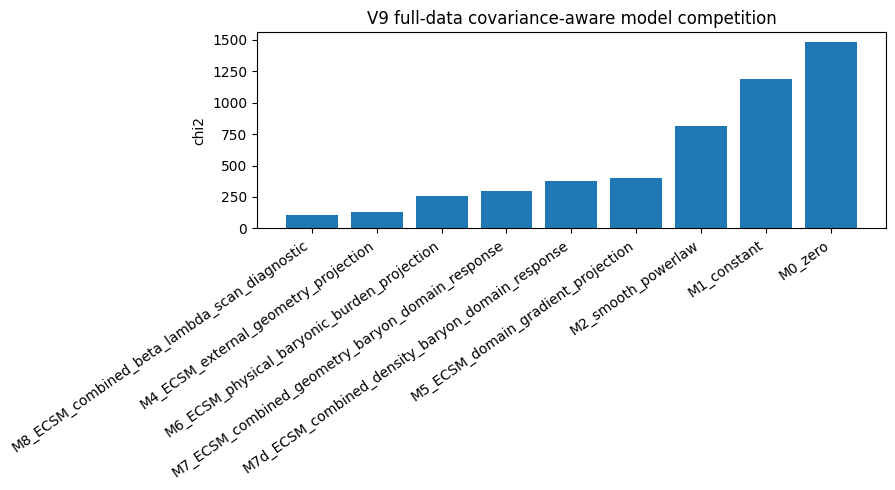

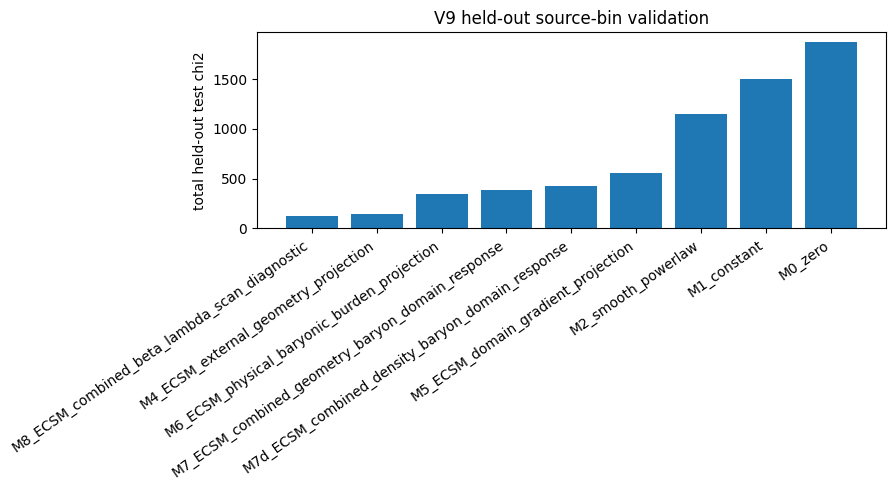

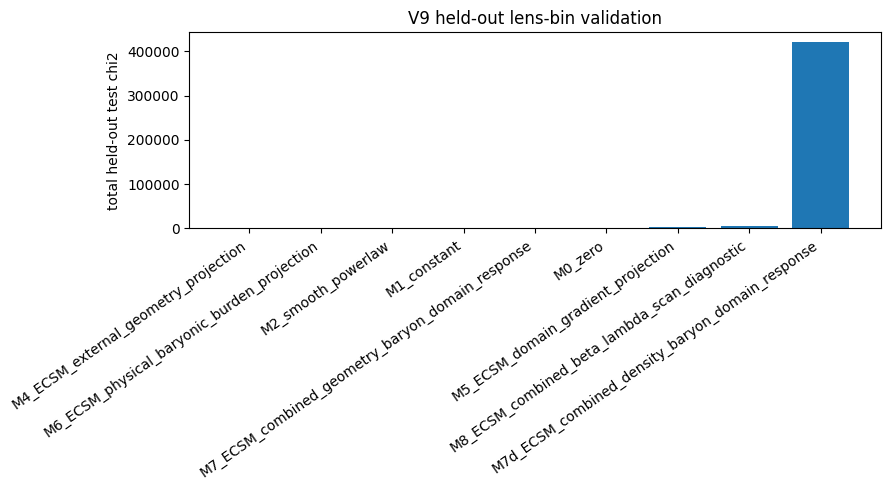

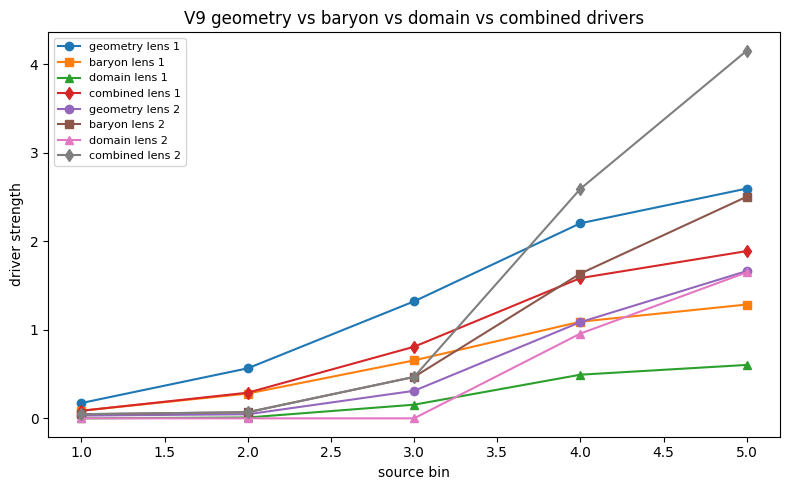

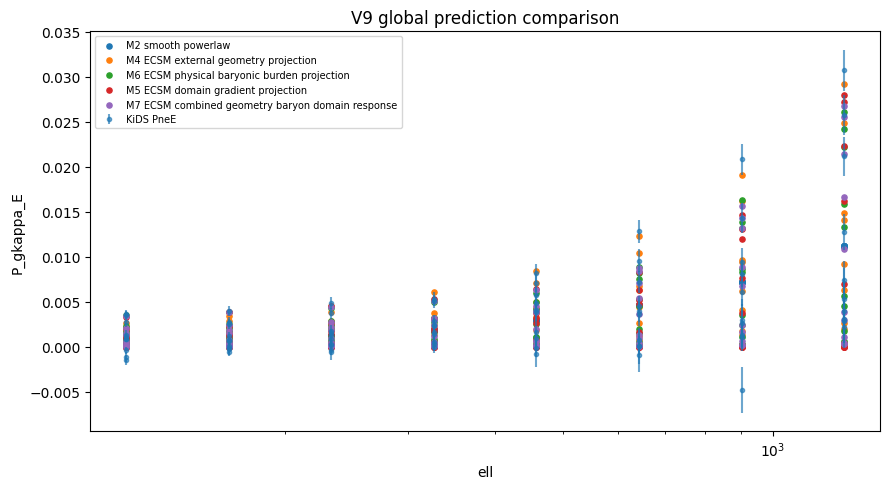

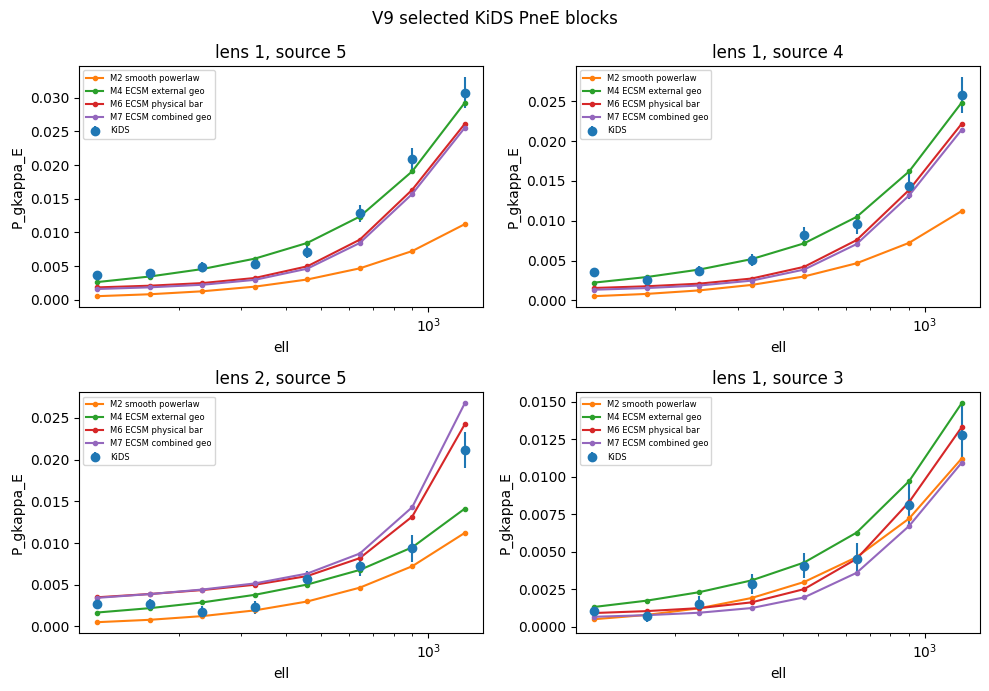

Figures saved in: /content/ecsm_kids_lephare_combined_baryon_domain_v9_out/figures


In [10]:
# CELL 09 — PREDICTIONS AND FIGURES
banner("CELL 09 — PREDICTIONS AND FIGURES")

pred_df = vec.copy()
for name in model_names:
    if name in fits_dict:
        pred_df[name] = predict_by_name(name, fits_dict[name])
    elif name == "M0_zero":
        pred_df[name] = 0.0
    else:
        pred_df[name] = predict_by_name(name, fit_model_by_name(name, np.ones(N, dtype=bool)))

pred_df.to_csv(TAB / "v9_predictions.csv", index=False)
display(pred_df.head())

# Model competition
plt.figure(figsize=(9,5))
plot_res = res.sort_values("chi2")
plt.bar(plot_res["model"], plot_res["chi2"])
plt.ylabel("chi2")
plt.title("V9 full-data covariance-aware model competition")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(FIG / "v9_model_competition_chi2.png", dpi=180)
plt.show()

# Held-out source
plt.figure(figsize=(9,5))
s = source_summary.sort_values("total_test_chi2")
plt.bar(s["model"], s["total_test_chi2"])
plt.ylabel("total held-out test chi2")
plt.title("V9 held-out source-bin validation")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(FIG / "v9_heldout_sourcebin_validation.png", dpi=180)
plt.show()

# Held-out lens
plt.figure(figsize=(9,5))
s = lens_summary.sort_values("total_test_chi2")
plt.bar(s["model"], s["total_test_chi2"])
plt.ylabel("total held-out test chi2")
plt.title("V9 held-out lens-bin validation")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(FIG / "v9_heldout_lensbin_validation.png", dpi=180)
plt.show()

# Driver comparison
plt.figure(figsize=(8,5))
for lb in sorted(geom.lens_bin.unique()):
    g = geom[geom.lens_bin == lb].sort_values("source_bin")
    plt.plot(g["source_bin"], g["external_geometry_driver"], marker="o", label=f"geometry lens {lb}")
    plt.plot(g["source_bin"], g["geometry_burden_driver"], marker="s", label=f"baryon lens {lb}")
    plt.plot(g["source_bin"], g["domain_gradient_driver"], marker="^", label=f"domain lens {lb}")
    plt.plot(g["source_bin"], g["combined_driver_frozen"], marker="d", label=f"combined lens {lb}")
plt.xlabel("source bin")
plt.ylabel("driver strength")
plt.title("V9 geometry vs baryon vs domain vs combined drivers")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG / "v9_driver_comparison_by_bin.png", dpi=180)
plt.show()

# Global predictions
plt.figure(figsize=(9,5))
main_preds = [
    "M2_smooth_powerlaw",
    "M4_ECSM_external_geometry_projection",
    "M6_ECSM_physical_baryonic_burden_projection",
    "M5_ECSM_domain_gradient_projection",
    "M7_ECSM_combined_geometry_baryon_domain_response",
]
plt.errorbar(vec["ell"], vec["Pgk_E"], yerr=vec["sigma_diag"], fmt="o", ms=3, alpha=0.65, label="KiDS PneE")
for name in main_preds:
    plt.scatter(vec["ell"], pred_df[name], s=14, label=name.replace("_", " "))
plt.xscale("log")
plt.xlabel("ell")
plt.ylabel("P_gkappa_E")
plt.title("V9 global prediction comparison")
plt.legend(fontsize=7)
plt.tight_layout()
plt.savefig(FIG / "v9_global_prediction_comparison.png", dpi=180)
plt.show()

# Selected blocks
selected = [(1,5), (1,4), (2,5), (1,3)]
fig, axes = plt.subplots(2, 2, figsize=(10,7))
axes = axes.ravel()
for ax, (lb, sb) in zip(axes, selected):
    m = (vec["lens_bin"] == lb) & (vec["source_bin"] == sb)
    ax.errorbar(vec.loc[m,"ell"], vec.loc[m,"Pgk_E"], yerr=vec.loc[m,"sigma_diag"], fmt="o", label="KiDS")
    for name in ["M2_smooth_powerlaw", "M4_ECSM_external_geometry_projection", "M6_ECSM_physical_baryonic_burden_projection", "M7_ECSM_combined_geometry_baryon_domain_response"]:
        ax.plot(vec.loc[m,"ell"], pred_df.loc[m,name], marker=".", label=name.replace("_"," ")[:20])
    ax.set_xscale("log")
    ax.set_title(f"lens {lb}, source {sb}")
    ax.set_xlabel("ell")
    ax.set_ylabel("P_gkappa_E")
    ax.legend(fontsize=6)
plt.suptitle("V9 selected KiDS PneE blocks")
plt.tight_layout()
plt.savefig(FIG / "v9_selected_block_model_comparison.png", dpi=180)
plt.show()

print("Figures saved in:", FIG)

In [11]:
# CELL 10 — README / SUMMARY REPORT
banner("CELL 10 — README / SUMMARY REPORT")

def md_table(df):
    return df.to_markdown(index=False)

best = res.iloc[0].to_dict()

readme = f"""
# {RUN_NAME}

## Purpose

This V9 notebook tests whether the KiDS-1000 `PneE` galaxy--galaxy lensing bandpower vector is better represented by the ECSM combined response chain:

```text
lens/source geometry
× physical stellar-mass burden
× domain-boundary-gradient correction
× finite-response kernel
→ predicted P_gkappa_E(ell)
```

The main V9 model is:

```text
M7_ECSM_combined_geometry_baryon_domain_response
```

## Dataset

- Source repository: KiDS-WL `Cat_to_Obs_K1000_P1`
- FITS file: `{FITS_PATH.name}`
- Observable: `PneE`
- Data points: {N}
- Lens bins: {vec.lens_bin.nunique()}
- Source bins: {vec.source_bin.nunique()}
- Ell range: {vec.ell.min():.6f} to {vec.ell.max():.6f}
- Covariance shape: {C.shape}
- Covariance method: {cov_method}

## Physical baryonic catalogue

- Catalogue path: `{LEPHARE_PATH}`
- Redshift column: `{z_col}`
- Stellar mass column: `{mass_col}`
- Mass interpretation: `{mass_interpretation}`
- Usable rows after cuts: {len(tmp)}
- Burden table: `tables/v9_physical_stellar_mass_burden_by_lens_bin.csv`

## V9 drivers

```text
external_geometry_driver = lens/source projection proxy
geometry_burden_driver = external_geometry_driver × physical_stellar_burden_norm
domain_gradient_driver = geometry_burden_driver × domain_boundary_gradient_chi
combined_driver_frozen = external_geometry_driver × physical_stellar_burden_norm × (1 + domain_boundary_gradient_chi)
```

Lens-specific response scales:

```json
{json.dumps({int(k): float(v) for k,v in ellB_by_lens.items()}, indent=2)}
```

## Full-data competition

{md_table(res)}

## Held-out source-bin validation

{md_table(source_summary)}

## Held-out lens-bin validation

{md_table(lens_summary)}

## Best full-data model

```json
{json.dumps({k: (v if isinstance(v, (str,int,float,bool,dict,list,type(None))) else str(v)) for k,v in best.items()}, indent=2)}
```

## Interpretation guardrail

This is a physical-baryonic combined-response bridge, not yet the final catalogue-matched first-principles weak-lensing prediction.

The LePhare bright-galaxy catalogue supplies real physical stellar masses, but it may not be a one-to-one foreground-lens catalogue match to the exact BOSS/2dFLenS lens populations used in the KiDS-1000 `PneE` bandpower file. Therefore, the strongest defensible claim is that V9 tests the ECSM transition from geometry-only and domain-gradient bridges toward a physical stellar-burden response chain.

A decisive next step would use the exact foreground lens catalogue with stellar mass/luminosity/size information and repeat this model comparison.
"""

print(readme)
(OUT / "README.md").write_text(readme)
print("Saved:", OUT / "README.md")


CELL 10 — README / SUMMARY REPORT

# ECSM_KiDS_LePhare_CombinedBaryonDomainResponse_V9

## Purpose

This V9 notebook tests whether the KiDS-1000 `PneE` galaxy--galaxy lensing bandpower vector is better represented by the ECSM combined response chain:

```text
lens/source geometry
× physical stellar-mass burden
× domain-boundary-gradient correction
× finite-response kernel
→ predicted P_gkappa_E(ell)
```

The main V9 model is:

```text
M7_ECSM_combined_geometry_baryon_domain_response
```

## Dataset

- Source repository: KiDS-WL `Cat_to_Obs_K1000_P1`
- FITS file: `bp_KIDS1000_BlindC_no_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits`
- Observable: `PneE`
- Data points: 80
- Lens bins: 2
- Source bins: 5
- Ell range: 118.441992 to 1266.442730
- Covariance shape: (80, 80)
- Covariance method: cholesky

## Physical baryonic catalogue

- Catalogue path: `/content/drive/MyDrive/KiDS_DR4_brightsample_LePhare.fits`
- Redshift column: `REDSHIFT`
- S

In [12]:
# CELL 11 — ZIP OUTPUTS AND DOWNLOAD
banner("CELL 11 — ZIP OUTPUTS AND DOWNLOAD")

zip_path = Path("/content") / f"{RUN_NAME}_outputs.zip"
if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for folder in [TAB, FIG]:
        for f in folder.rglob("*"):
            if f.is_file():
                zf.write(f, f.relative_to(OUT))
    if (OUT / "README.md").exists():
        zf.write(OUT / "README.md", "README.md")

print("ZIP ready:", zip_path)
print("Size MB:", zip_path.stat().st_size / 1e6)

try:
    from google.colab import files
    files.download(str(zip_path))
except Exception as e:
    print("Colab download call skipped:", repr(e))

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    drive_dir = Path("/content/drive/MyDrive/ECSM_KiDS_data")
    drive_dir.mkdir(parents=True, exist_ok=True)
    shutil.copy2(zip_path, drive_dir / zip_path.name)
    print("Copied to Drive:", drive_dir / zip_path.name)
except Exception as e:
    print("Drive copy skipped:", repr(e))


CELL 11 — ZIP OUTPUTS AND DOWNLOAD
ZIP ready: /content/ECSM_KiDS_LePhare_CombinedBaryonDomainResponse_V9_outputs.zip
Size MB: 1.007971


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copied to Drive: /content/drive/MyDrive/ECSM_KiDS_data/ECSM_KiDS_LePhare_CombinedBaryonDomainResponse_V9_outputs.zip
